# 05 — LoRA SFT of Gemma on SAC Trajectories · Google Colab (Unsloth)

**Phase 2 / Month 2** · MSc Thesis — ECLIPSE project  
Supervisor: Dr. Panagiotis Kasnesis | Student: Antonios Bastoulis

---

Companion to notebook **04** (local). Pipeline:

1. Pull the SAC distillation JSONL produced by 04.
2. Load Gemma-3n E4B via **Unsloth** (`FastModel`) — 4-bit + LoRA, ~2× faster
   training and ~50% less VRAM than the vanilla HF stack.
3. Run SFT with TRL's `SFTTrainer` on Unsloth's optimized model.
4. Evaluate the fine-tuned SLM in CityLearn (6-building single-agent rollout)
   against RBC and the no-control baseline using the canonical `src.eval` KPIs.

Reference: https://unsloth.ai/docs/models/gemma-4/train

Set runtime to **T4 GPU** (free tier) — Unsloth fits Gemma-3n E4B + LoRA comfortably.

## § 0 — Runtime & Config
> **Edit this cell only.** Nothing else needs changing.

In [1]:
import os, sys, subprocess, time, warnings, json, random
import numpy as np

# ── Repo + dataset selection ──────────────────────────────────────────────
GITHUB_REPO    = "https://github.com/antonisbast/eclipse-thesis.git"  # adjust if needed
REPO_DIR       = "/content/eclipse-thesis"
DATASET_GLOB   = "notebooks/artifacts/sft_datasets/sac_*.jsonl"  # picks newest match

# ── Model selection ───────────────────────────────────────────────────────
# Unsloth-optimized Gemma 4 E4B
MODEL_ID:       str  = "unsloth/gemma-4-E4B-it"
LOAD_IN_4BIT:   bool = True
MAX_NEW_TOKENS: int  = 200

# ── LoRA / SFT hyperparameters ────────────────────────────────────────────
LORA_R         = 16
LORA_ALPHA     = 32
LORA_DROPOUT   = 0.0    # Unsloth recommends 0 for fastest path
EPOCHS         = 3
BATCH_SIZE     = 2
GRAD_ACCUM     = 8      # effective batch 16
LEARNING_RATE  = 5e-5
MAX_SEQ_LEN    = 1024

# ── Evaluation slice ──────────────────────────────────────────────────────
EVAL_START     = 4000           # mid-summer slice, batteries primed by then
EVAL_LEN       = 168            # 1-week eval; raise to 8760 for full year

# ── Misc ──────────────────────────────────────────────────────────────────
HF_TOKEN: str = ""
SEED          = 42

try:
    import torch
    if torch.cuda.is_available():
        _gpu  = torch.cuda.get_device_name(0)
        _vram = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f"✓ GPU: {_gpu}  ({_vram:.1f} GB VRAM)")
    else:
        print("⚠  No GPU — set Runtime → Change runtime type → T4 GPU")
except ImportError:
    print("torch not yet installed — will be in § 1")

✓ GPU: NVIDIA L4  (23.7 GB VRAM)


## § 1 — Install Dependencies

In [2]:
# CityLearn (for evaluation rollout)
!pip install -q numpy gymnasium doe-xstock nrel-pysam
!pip install -q CityLearn --no-deps
print("✓ CityLearn installed")

✓ CityLearn installed


In [3]:
# Unsloth installs its own pinned versions of transformers, peft, trl,
# bitsandbytes, accelerate. Per Unsloth's Colab quick-start, install
# unsloth + unsloth_zoo first, then let it pull compatible deps.
!pip install -q --upgrade pip
!pip install -q --no-deps "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install -q --no-deps git+https://github.com/unslothai/unsloth-zoo.git
!pip install -q --upgrade transformers peft trl accelerate bitsandbytes datasets sentencepiece torchao
# triton + xformers are pre-installed on Colab; ensure compatible version for torch
!pip install -q triton==3.6.0
print("✓ Unsloth + SFT stack installed")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✓ Unsloth + SFT stack installed


## § 2 — Clone Repository (pulls `src/sft.py` and the JSONL dataset)

In [4]:
if not os.path.exists(REPO_DIR):
    res = subprocess.run(["git", "clone", GITHUB_REPO, REPO_DIR],
                         capture_output=True, text=True)
    print(res.stdout or res.stderr)
else:
    res = subprocess.run(["git", "-C", REPO_DIR, "pull"],
                         capture_output=True, text=True)
    print("Repo present —", res.stdout.strip() or "up to date")

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

if HF_TOKEN:
    from huggingface_hub import login
    login(token=HF_TOKEN, add_to_git_credential=False)

Repo present — Already up to date.


## § 3 — Load Distillation Dataset

In [5]:
import glob
from pathlib import Path

from src.sft import filter_uninformative_rows

candidates = sorted(glob.glob(os.path.join(REPO_DIR, DATASET_GLOB)))
assert candidates, f"No JSONL matching {DATASET_GLOB} in repo. Run notebook 04 + push first."
JSONL_PATH = candidates[-1]
print(f"Using dataset: {JSONL_PATH}")

raw_rows = [json.loads(l) for l in Path(JSONL_PATH).read_text().strip().split("\n")]
print(f"Raw examples : {len(raw_rows)}")

# Drop rows where EVERY building's action is a physical no-op
# (discharge from SoC≈0, charge into SoC≈100, or |a|<0.05).
# Removes ~30-35% of rows and rebalances the action distribution.
raw_rows = filter_uninformative_rows(raw_rows)
print(f"After filter : {len(raw_rows)}")

print("\nFirst row preview:")
print("  prompt :", raw_rows[0]["prompt"][:200].replace("\n", " | "))
print("  response:", raw_rows[0]["response"][:200].replace("\n", " | "))


Using dataset: /content/eclipse-thesis/notebooks/artifacts/sft_datasets/sac_merlin_distill_20260509_235739.jsonl
Raw examples : 8759
After filter : 5791

First row preview:
  prompt : STATE: | Month 8, Mon 07:00  |  price=0.220 (LOW)  |  carbon=0.191 (MID) | Forecast:  price+6h=LOW  price+12h=PEAK  solar+6h=HIGH | Buildings: |   B0: SoC=  0.0%  load=0.62 kWh  last_net=+0.36 kWh  solar=HIGH
  response: <action building=0>CHARGE_20</action> | <action building=1>DISCHARGE_20</action> | <action building=2>DISCHARGE_20</action> | <action building=3>DISCHARGE_40</action> | <action building=4>DISCHARGE_20</action


## § 4 — Load Gemma + Attach LoRA (Unsloth `FastModel`)

`FastModel.from_pretrained` returns the model **and** tokenizer with Unsloth's
kernels patched in. `FastModel.get_peft_model` attaches LoRA adapters in
Unsloth-optimized form (no `prepare_model_for_kbit_training` needed).

In [6]:
from unsloth import FastModel
import torch
import time

# Clear any lingering memory from previous failed runs
torch.cuda.empty_cache()

_t0 = time.time()
model, tokenizer = FastModel.from_pretrained(
    model_name      = MODEL_ID,
    max_seq_length  = MAX_SEQ_LEN,
    dtype           = None,  # Let Unsloth auto-detect optimal precision for Gemma 4
    load_in_4bit    = LOAD_IN_4BIT,
    full_finetuning = False,
    token           = HF_TOKEN or None,
)
print(f"Base model loaded in {time.time()-_t0:.1f}s")

model = FastModel.get_peft_model(
    model,
    finetune_vision_layers     = False,   # text-only distillation
    finetune_language_layers   = True,
    finetune_attention_modules = True,
    finetune_mlp_modules       = True,
    r              = LORA_R,
    lora_alpha     = LORA_ALPHA,
    lora_dropout   = LORA_DROPOUT,
    bias           = "none",
    random_state   = SEED,
)
model.print_trainable_parameters()

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.5.2: Fast Gemma4 patching. Transformers: 5.8.0.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.034 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

Base model loaded in 39.9s
trainable params: 34,881,536 || all params: 7,975,982,368 || trainable%: 0.4373


## § 5 — Build HF Dataset with Gemma Chat Template

Gemma rejects the `system` role, so the SFT prompt is merged into the user
turn (same workaround as notebook 03's `LocalHFProvider`).

In [7]:
from datasets import Dataset

from src.sft import make_sft_prompt

N_BUILDINGS   = 6
SYSTEM_PROMPT = make_sft_prompt(N_BUILDINGS)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

_is_gemma = "gemma" in MODEL_ID.lower()

def to_chat(row):
    if _is_gemma:
        msgs = [
            {"role": "user",      "content": f"{SYSTEM_PROMPT}\n\n{row['prompt']}"},
            {"role": "assistant", "content": row["response"]},
        ]
    else:
        msgs = [
            {"role": "system",    "content": SYSTEM_PROMPT},
            {"role": "user",      "content": row["prompt"]},
            {"role": "assistant", "content": row["response"]},
        ]
    text = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=False)
    return {"text": text}

ds = Dataset.from_list(raw_rows).map(to_chat, remove_columns=["prompt", "response"])
print(f"Dataset built: {len(ds)} examples  |  fields: {ds.column_names}")
print("\nSample formatted text (truncated):")
print(ds[0]["text"][:500])
print("...")

Map:   0%|          | 0/5791 [00:00<?, ? examples/s]

Dataset built: 5791 examples  |  fields: ['t', 'actions_float', 'reward', 'text']

Sample formatted text (truncated):
<bos><|turn>user
You are an energy management agent for 6 buildings. Goal: minimize grid dependency and energy costs over time.

[Actions] — choose exactly one per building:
CHARGE_100, CHARGE_80, CHARGE_60, CHARGE_40, CHARGE_20, IDLE, DISCHARGE_20, DISCHARGE_40, DISCHARGE_60, DISCHARGE_80, DISCHARGE_100

[State Variables & Environment]
- 'price': Current cost of grid electricity. PEAK indicates high cost.
- 'solar': Renewable energy generated locally.
- 'load': Energy demanded by the building's
...


In [8]:
import trl
import inspect

# Let's search for DataCollatorForCompletionOnlyLM in the trl package
found = False
for name, obj in inspect.getmembers(trl):
    if 'DataCollatorForCompletionOnlyLM' in name:
        print(f"Found in trl: {name}")
        found = True

try:
    import trl.trainer
    for name, obj in inspect.getmembers(trl.trainer):
        if 'DataCollatorForCompletionOnlyLM' in name:
            print(f"Found in trl.trainer: {name}")
            found = True
except ImportError:
    pass

try:
    from trl.trainer import utils
    for name, obj in inspect.getmembers(utils):
        if 'DataCollatorForCompletionOnlyLM' in name:
            print(f"Found in trl.trainer.utils: {name}")
            found = True
except ImportError:
    pass

if not found:
    print("Could not find DataCollatorForCompletionOnlyLM in common trl modules. Let's check trl version:", trl.__version__)

Could not find DataCollatorForCompletionOnlyLM in common trl modules. Let's check trl version: 1.4.0


## § 6 — Train (TRL `SFTTrainer` on Unsloth model)

Unsloth's patched model + tokenizer plug straight into TRL's `SFTTrainer`.
We train causal-LM loss on the full sequence (prompt + completion) — fine
for behaviour-cloning distillation. For loss-on-completion-only, swap to
`DataCollatorForCompletionOnlyLM`.

In [11]:
!pip install -q triton==3.6.0
from trl import SFTTrainer, SFTConfig
from transformers import DataCollatorForLanguageModeling
import time

OUT_DIR = f"/content/sft_out_{time.strftime('%Y%m%d_%H%M%S')}"

sft_cfg = SFTConfig(
    output_dir                  = OUT_DIR,
    num_train_epochs            = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    gradient_accumulation_steps = GRAD_ACCUM,
    learning_rate               = LEARNING_RATE,
    max_length                  = MAX_SEQ_LEN,
    logging_steps               = 25,
    save_strategy               = "no",
    bf16                        = True,
    fp16                        = False,
    optim                       = "adamw_8bit",   # Unsloth-recommended on T4
    warmup_ratio                = 0.03,
    lr_scheduler_type           = "linear",
    report_to                   = "none",
    seed                        = SEED,
    dataset_text_field          = "text",
)

# Fallback to standard LM collator due to missing DataCollatorForCompletionOnlyLM in current TRL version.
# Loss will be computed over the whole sequence.
collator = DataCollatorForLanguageModeling(
    tokenizer = tokenizer,
    mlm       = False,
)

trainer = SFTTrainer(
    model           = model,
    args            = sft_cfg,
    train_dataset   = ds,
    processing_class= tokenizer,
    data_collator   = collator,
)

_t0 = time.time()
trainer.train()
print(f"\nSFT done in {time.time()-_t0:.1f}s")

ADAPTER_DIR = f"{OUT_DIR}/lora_adapter"
trainer.model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
print(f"Adapter saved: {ADAPTER_DIR}")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/5791 [00:00<?, ? examples/s]

[transformers] ==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 5,791 | Num Epochs = 3 | Total steps = 1,086
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 8 x 1) = 16
 "-____-"     Trainable parameters = 34,881,536 of 7,975,982,368 (0.44% trained)


Step,Training Loss
25,0.017837
50,0.017593
75,0.017356
100,0.017308
125,0.017096
150,0.016970
175,0.016763
200,0.016817
225,0.016590
250,0.016755



SFT done in 12963.1s


[transformers] Unsloth: Restored added_tokens_decoder metadata in /content/sft_out_20260510_221105/lora_adapter/tokenizer_config.json.


Adapter saved: /content/sft_out_20260510_221105/lora_adapter


## § 7 — Build Inference Provider (Unsloth fast inference)

`FastModel.for_inference(model)` enables Unsloth's 2× faster inference path
(disables training-only autograd hooks). Same `.complete()` / `.step()` API
as notebook 03's `LocalHFProvider`, so the rollout helper below is unchanged.

In [12]:
import logging, re
from src.sft import parse_actions, make_sft_prompt

_logger = logging.getLogger("sft_slm")
_ACTION_RE = re.compile(r"<action\s+building\s*=\s*\d+\s*>", re.IGNORECASE)

FastModel.for_inference(trainer.model)  # 2× faster inference


class SFTProvider:
    """Inference provider wrapping the LoRA-fine-tuned Unsloth model."""

    def __init__(self, model, tokenizer, max_new_tokens: int = 200):
        self.model         = model.eval()
        self.tokenizer     = tokenizer
        self.max_new_tokens= max_new_tokens
        self.label         = f"sft:{MODEL_ID.split('/')[-1]}"
        self._is_gemma     = "gemma" in MODEL_ID.lower()
        self._device       = next(model.parameters()).device

    def complete(self, system: str, user: str, max_tokens=None) -> str:
        max_new = max_tokens or self.max_new_tokens
        if self._is_gemma:
            msgs = [{"role": "user", "content": f"{system}\n\n{user}"}]
        else:
            msgs = [{"role": "system", "content": system},
                    {"role": "user",   "content": user}]
        enc = self.tokenizer.apply_chat_template(
            msgs, tokenize=True, add_generation_prompt=True,
            return_tensors="pt", return_dict=True,
        ).to(self._device)
        with torch.no_grad():
            out = self.model.generate(
                **enc,
                max_new_tokens=max_new,
                do_sample=False,
                pad_token_id=self.tokenizer.pad_token_id,
            )
        new_tokens = out[0][enc["input_ids"].shape[1]:]
        return self.tokenizer.decode(new_tokens, skip_special_tokens=True)

    def step(self, state_text: str, system=None, n_buildings: int = 6,
             max_retries: int = 2, **kw):
        sys_p = system or make_sft_prompt(n_buildings)
        last  = ""
        for _ in range(max_retries):
            last = self.complete(sys_p, f"STATE:\n{state_text}")
            if _ACTION_RE.search(last):
                return parse_actions(last, n_buildings), last, False
        return [0.0]*n_buildings, last, True


slm = SFTProvider(trainer.model, tokenizer, max_new_tokens=MAX_NEW_TOKENS)
print(f"Provider ready: {slm.label}")

Provider ready: sft:gemma-4-E4B-it


In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## § 8 — Evaluation Environment Factory (Colab)

In [14]:
import citylearn
from citylearn.citylearn import CityLearnEnv
from citylearn.agents.rbc import BasicBatteryRBC
from src.env import (
    snapshot_state, MERLINReward, OBSERVATIONS_LLM, ACTIVE_ACTIONS, BUILDINGS,
)
from src.eval import evaluate, comparison_table
from src.sft  import render_state

warnings.filterwarnings("ignore")
np.random.seed(SEED); random.seed(SEED)

def make_colab_env(start=0, end=8758, buildings=None) -> CityLearnEnv:
    env = CityLearnEnv(
        schema="citylearn_challenge_2022_phase_all",
        buildings=buildings if buildings is not None else BUILDINGS,
        central_agent=False,
        active_actions=ACTIVE_ACTIONS,
        active_observations=OBSERVATIONS_LLM,
        random_seed=SEED,
        simulation_start_time_step=start,
        simulation_end_time_step=end,
    )
    env.reward_function = MERLINReward(env.get_metadata())
    return env

print(f"CityLearn {citylearn.__version__}")

CityLearn 2.5.0


## § 9 — Rollout Helpers

In [15]:
def run_slm_policy(name: str, provider, start=EVAL_START, length=EVAL_LEN,
                   n_buildings: int = N_BUILDINGS, verbose_every: int = 24):
    env = make_colab_env(start=start, end=start+length-1)
    env.reset()
    sys_p = make_sft_prompt(n_buildings)
    done, t, t0, n_fb = False, 0, time.time(), 0
    while not done:
        snap = snapshot_state(env)
        state_text = render_state(snap)
        acts, raw, fb = provider.step(state_text, system=sys_p, n_buildings=n_buildings)
        n_fb += int(fb)
        _, _, term, trunc, _ = env.step([[float(a)] for a in acts])
        done = bool(term or trunc)
        if verbose_every and (t % verbose_every == 0):
            elapsed = time.time() - t0
            print(f"  t={t:4d} | {elapsed:.0f}s | fallbacks={n_fb}")
        t += 1
    print(f"[{name}] {t} steps in {time.time()-t0:.1f}s | fallbacks={n_fb}/{t}")
    return env


def run_rbc(start=EVAL_START, length=EVAL_LEN):
    env = make_colab_env(start=start, end=start+length-1)
    BasicBatteryRBC(env=env).learn(episodes=1)
    return env


def run_noop(start=EVAL_START, length=EVAL_LEN):
    env = make_colab_env(start=start, end=start+length-1)
    env.reset()
    n_b = len(env.buildings)
    done = False
    while not done:
        _, _, term, trunc, _ = env.step([[0.0] for _ in range(n_b)])
        done = bool(term or trunc)
    return env

## § 10 — Run Baselines + SFT-SLM

In [16]:
print("── No-control baseline ──")
env_noop = run_noop()

print("\n── RBC ──")
env_rbc  = run_rbc()

print(f"\n── SFT SLM ({slm.label}) ──")
env_slm  = run_slm_policy("sft_slm", slm)

── No-control baseline ──


INFO:root:The dataset names DNE in cache. Will download from intelligent-environments-lab/CityLearn/tree/v2.5.0 GitHub repository and write to /root/.cache/citylearn/v2.5.0/dataset_names.json. Next time DataSet.get_dataset_names is called, it will read from cache unless DataSet.clear_cache is run first.
INFO:root:Go here /root/.cache/citylearn/v2.5.0/datasets/citylearn_challenge_2022_phase_all/schema.json 
INFO:root:The citylearn_challenge_2022_phase_all dataset DNE in cache. Will download from intelligent-environments-lab/CityLearn/tree/v2.5.0 GitHub repository and write to /root/.cache/citylearn/v2.5.0/datasets. Next time DataSet.get_dataset('citylearn_challenge_2022_phase_all') is called, it will read from cache unless DataSet.clear_cache is run first.
INFO:root:The PV sizing data DNE in cache. Will download from intelligent-environments-lab/CityLearn/tree/v2.5.0 GitHub repository and write to /root/.cache/citylearn/v2.5.0/misc. Next time DataSet.get_pv_sizing_data is called, it wil


── RBC ──


INFO:root:Go here /root/.cache/citylearn/v2.5.0/datasets/citylearn_challenge_2022_phase_all/schema.json 



── SFT SLM (sft:gemma-4-E4B-it) ──
  t=   0 | 30s | fallbacks=0
  t=  24 | 505s | fallbacks=0
  t=  48 | 971s | fallbacks=0
  t=  72 | 1436s | fallbacks=0
  t=  96 | 1900s | fallbacks=0
  t= 120 | 2360s | fallbacks=0
  t= 144 | 2824s | fallbacks=0
[sft_slm] 167 steps in 3253.3s | fallbacks=0/167


## § 11 — Evaluation

In [17]:
import pandas as pd

# Bypass src.eval and use CityLearn's native evaluation
df_noop = env_noop.evaluate()
df_noop['Policy'] = 'No-Control'

df_rbc = env_rbc.evaluate()
df_rbc['Policy'] = 'RBC'

df_slm = env_slm.evaluate()
df_slm['Policy'] = slm.label

# Combine the results
all_kpis = pd.concat([df_noop, df_rbc, df_slm])

# Filter for district-level KPIs and pivot for easy comparison
try:
    district_kpis = all_kpis[all_kpis['level'] == 'district']
    comparison_df = district_kpis.pivot(index='cost_function', columns='Policy', values='value')
    print("District-Level KPIs (Lower is generally better):")
    display(comparison_df)
except Exception as e:
    # Fallback if the dataframe structure is different than expected
    print(f"Pivot failed: {e}\nRaw KPI Data:")
    display(all_kpis)

District-Level KPIs (Lower is generally better):


Policy,No-Control,RBC,sft:gemma-4-E4B-it
cost_function,,,
all_time_peak_average,1.000000,1.009531,1.000000
annual_normalized_unserved_energy_total,0.000000,0.000000,0.000000
carbon_emissions_total,1.000000,1.013340,0.972955
cost_total,1.000000,0.938358,0.894868
daily_one_minus_load_factor_average,0.994377,1.054950,0.977140
daily_peak_average,1.000000,1.162404,1.011428
discomfort_cold_delta_average,0.000000,0.000000,0.000000
discomfort_cold_delta_maximum,0.000000,0.000000,0.000000
discomfort_cold_delta_minimum,0.000000,0.000000,0.000000


## § 12 — Persist Adapter to Drive (optional)

In [18]:
from google.colab import drive

# This will prompt you to authorize Google Drive access
drive.mount('/content/drive')

# Ensure the target directory exists
!mkdir -p /content/drive/MyDrive/eclipse-thesis/sft_adapters/

# Copy the saved adapter to your Drive
!cp -r {ADAPTER_DIR} /content/drive/MyDrive/eclipse-thesis/sft_adapters/

print(f"\nAdapter successfully backed up to Google Drive!")
print(f"Look for it in: MyDrive/eclipse-thesis/sft_adapters/")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Adapter successfully backed up to Google Drive!
Look for it in: MyDrive/eclipse-thesis/sft_adapters/


## § 13 — Battery State of Charge (SOC) Visualization

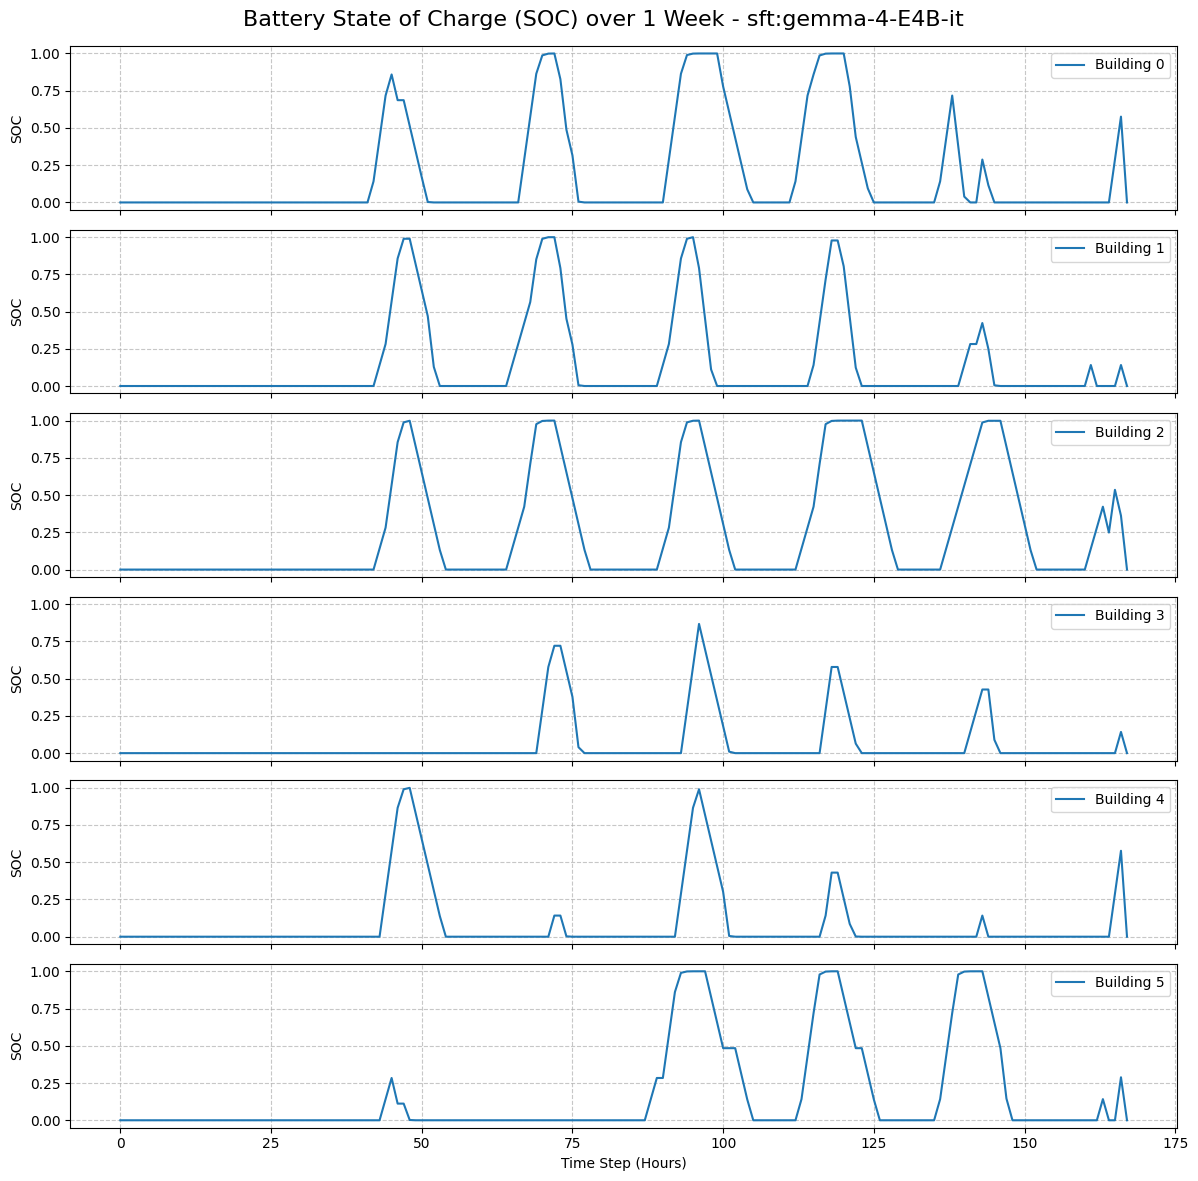

In [19]:
import matplotlib.pyplot as plt
import numpy as np

n_buildings = len(env_slm.buildings)
fig, axes = plt.subplots(nrows=n_buildings, ncols=1, figsize=(12, 2 * n_buildings), sharex=True)

if n_buildings == 1:
    axes = [axes]

for i, b in enumerate(env_slm.buildings):
    # Extract the SOC history for the episode
    soc_history = b.electrical_storage.soc

    axes[i].plot(soc_history, label=f'Building {i}', color='tab:blue', linewidth=1.5)
    axes[i].set_ylabel('SOC')
    axes[i].set_ylim(-0.05, 1.05)  # SOC is strictly between 0 and 1
    axes[i].legend(loc='upper right')
    axes[i].grid(True, linestyle='--', alpha=0.7)

axes[-1].set_xlabel('Time Step (Hours)')
fig.suptitle(f'Battery State of Charge (SOC) over 1 Week - {slm.label}', fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

## § 14 — Debugging: Inspect Raw SLM Output
Let's run a single step to see exactly what the model is generating.

In [20]:
from src.env import snapshot_state
from src.sft import render_state, make_sft_prompt

# Create a test environment and get the first state
env_test = make_colab_env(start=EVAL_START, end=EVAL_START+5)
env_test.reset()
snap = snapshot_state(env_test)
state_text = render_state(snap)
sys_p = make_sft_prompt(N_BUILDINGS)

print("=== RAW SLM GENERATION TEST ===\n")
print("--- PROMPT STATE ---")
print(state_text[:500] + "\n... [truncated]")

print("\n--- MODEL RESPONSE ---")
# Run the complete method to get the raw string
raw_resp = slm.complete(sys_p, f"STATE:\n{state_text}")
print(raw_resp)

print("\n--- PARSED ACTIONS ---")
acts, raw, fallback = slm.step(state_text, system=sys_p, n_buildings=N_BUILDINGS)
print(f"Parsed actions: {acts}")
print(f"Did it trigger a fallback (parsing error)? {fallback}")

INFO:root:Go here /root/.cache/citylearn/v2.5.0/datasets/citylearn_challenge_2022_phase_all/schema.json 


=== RAW SLM GENERATION TEST ===

--- PROMPT STATE ---
Month 1, Sat 15:00  |  price=0.500 (PEAK)  |  carbon=0.175 (MID)
Forecast:  price+6h=LOW  price+12h=LOW  solar+6h=LOW
Buildings:
  B0: SoC=  0.0%  load=1.07 kWh  last_net=+0.00 kWh  solar=HIGH
  B1: SoC=  0.0%  load=0.86 kWh  last_net=+0.00 kWh  solar=HIGH
  B2: SoC=  0.0%  load=0.54 kWh  last_net=+0.00 kWh  solar=HIGH
  B3: SoC=  0.0%  load=0.61 kWh  last_net=+0.00 kWh  solar=HIGH
  B4: SoC=  0.0%  load=0.15 kWh  last_net=+0.00 kWh  solar=HIGH
  B5: SoC=  0.0%  load=2.36 kWh  last_net=+0.00 kWh
... [truncated]

--- MODEL RESPONSE ---
<action building=0>DISCHARGE_20</action>
<action building=1>DISCHARGE_20</action>
<action building=2>DISCHARGE_20</action>
<action building=3>DISCHARGE_20</action>
<action building=4>DISCHARGE_20</action>
<action building=5>DISCHARGE_40</action>

--- PARSED ACTIONS ---
Parsed actions: [-0.2, -0.2, -0.2, -0.2, -0.2, -0.4]
Did it trigger a fallback (parsing error)? False


## § 15 — 1-Day Inference Trace
Run a 24-hour rollout and print the exact states and responses for inspection.

In [21]:
print("=== 1-DAY INFERENCE TRACE ===")
# 24 steps for a single day
env_day = make_colab_env(start=EVAL_START, end=EVAL_START+23)
env_day.reset()
sys_p = make_sft_prompt(N_BUILDINGS)

done = False
step_idx = 0

while not done:
    print(f"\n{'='*40}")
    print(f" STEP {step_idx:02d}")
    print(f"{'='*40}")

    snap = snapshot_state(env_day)
    state_text = render_state(snap)

    print("[INPUT STATE]")
    # Printing the first few lines to keep output readable,
    # but we can print the whole thing if preferred.
    lines = state_text.split('\n')
    print('\n'.join(lines[:4]))
    print("  ... [buildings truncated] ...")

    acts, raw_resp, fallback = slm.step(state_text, system=sys_p, n_buildings=N_BUILDINGS)

    print("\n[MODEL OUTPUT]")
    print(raw_resp.strip())
    print(f"\n-> Parsed Actions: {acts} (Fallback: {fallback})")

    _, _, term, trunc, _ = env_day.step([[float(a)] for a in acts])
    done = bool(term or trunc)
    step_idx += 1


=== 1-DAY INFERENCE TRACE ===


INFO:root:Go here /root/.cache/citylearn/v2.5.0/datasets/citylearn_challenge_2022_phase_all/schema.json 



 STEP 00
[INPUT STATE]
Month 1, Sat 15:00  |  price=0.500 (PEAK)  |  carbon=0.175 (MID)
Forecast:  price+6h=LOW  price+12h=LOW  solar+6h=LOW
Buildings:
  B0: SoC=  0.0%  load=1.07 kWh  last_net=+0.00 kWh  solar=HIGH
  ... [buildings truncated] ...

[MODEL OUTPUT]
<action building=0>DISCHARGE_20</action>
<action building=1>DISCHARGE_20</action>
<action building=2>DISCHARGE_20</action>
<action building=3>DISCHARGE_20</action>
<action building=4>DISCHARGE_20</action>
<action building=5>DISCHARGE_40</action>

-> Parsed Actions: [-0.2, -0.2, -0.2, -0.2, -0.2, -0.4] (Fallback: False)

 STEP 01
[INPUT STATE]
Month 1, Sat 16:00  |  price=0.500 (PEAK)  |  carbon=0.186 (MID)
Forecast:  price+6h=LOW  price+12h=LOW  solar+6h=HIGH
Buildings:
  B0: SoC=  0.0%  load=0.97 kWh  last_net=+2.68 kWh  solar=NONE
  ... [buildings truncated] ...

[MODEL OUTPUT]
<action building=0>DISCHARGE_20</action>
<action building=1>DISCHARGE_20</action>
<action building=2>DISCHARGE_20</action>
<action building=3>DISCHA

## § 16 — Inspect the Exact Inference Prompt
Print the fully formatted prompt (with chat template tokens) sent to the model.

In [22]:
from src.env import snapshot_state
from src.sft import render_state, make_sft_prompt

# Get step 0 state
env_test = make_colab_env(start=EVAL_START, end=EVAL_START+1)
env_test.reset()
snap = snapshot_state(env_test)
state_text = render_state(snap)

sys_p = make_sft_prompt(N_BUILDINGS)
user_p = f"STATE:\n{state_text}"

# Combine them exactly as SFTProvider.complete() does for Gemma
msgs = [{"role": "user", "content": f"{sys_p}\n\n{user_p}"}]

# Apply the chat template to see the raw input string
raw_prompt = slm.tokenizer.apply_chat_template(
    msgs,
    tokenize=False,
    add_generation_prompt=True
)

print("=== EXACT MODEL INPUT PROMPT ===\n")
print(raw_prompt)

INFO:root:Go here /root/.cache/citylearn/v2.5.0/datasets/citylearn_challenge_2022_phase_all/schema.json 


=== EXACT MODEL INPUT PROMPT ===

<bos><|turn>user
You are an energy management agent for 6 buildings. Goal: minimize grid dependency and energy costs over time.

[Actions] — choose exactly one per building:
CHARGE_100, CHARGE_80, CHARGE_60, CHARGE_40, CHARGE_20, IDLE, DISCHARGE_20, DISCHARGE_40, DISCHARGE_60, DISCHARGE_80, DISCHARGE_100

[State Variables & Environment]
- 'price': Current cost of grid electricity. PEAK indicates high cost.
- 'solar': Renewable energy generated locally.
- 'load': Energy demanded by the building's operations. High load means the building needs a lot of power.
- 'SoC': Battery State of Charge (0% = empty, 100% = full).
- Charging stores energy. Doing so when solar is HIGH or price is LOW is efficient, but charging from the grid increases district demand.
- Discharging uses stored energy to serve the 'load', directly reducing grid dependency. This is highly beneficial when 'price' is PEAK or 'load' is high and SoC is sufficient.
- Forecast fields show anti

## § 17 — Inference with CoT Minimal Prompt
Testing the modified prompt that introduces Chain-of-Thought `<thought>` blocks and specific operational constraints.

In [23]:
def make_minimal_prompt(n_buildings: int = 6) -> str:
    """Prompt with variable semantics, indirect instructions, and Chain-of-Thought reasoning."""
    action_fmt = "\n".join(
        f"<action building={i}>YOUR_CHOICE</action>" for i in range(n_buildings)
    )
    return f"""\
You are an energy management agent for {n_buildings} buildings. Goal: minimize grid dependency and energy costs over time.

[Actions] — choose exactly one per building:
CHARGE_100, CHARGE_80, CHARGE_60, CHARGE_40, CHARGE_20, IDLE, DISCHARGE_20, DISCHARGE_40, DISCHARGE_60, DISCHARGE_80, DISCHARGE_100

[State Variables & Environment]
- 'price': Current cost of grid electricity. PEAK indicates high cost.
- 'solar': Renewable energy generated locally.
- 'load': Energy demanded by the building's operations. High load means the building needs a lot of power.
- 'SoC': Battery State of Charge (0% = empty, 100% = full).
- Charging stores energy. Doing so when solar is HIGH or price is LOW is efficient, but charging from the grid increases district demand.
- Discharging uses stored energy to serve the 'load', directly reducing grid dependency. This is highly beneficial when 'price' is PEAK or 'load' is high and SoC is sufficient.
- Forecast fields show anticipated conditions 6 or 12 hours ahead, helping you plan when to store or release energy.
-Avoid aggresive actions, prefer CHARGE_20,CHARGE_40,DISCHARGE_20 OR DISCHARGE_40.
-Never charge when SOC is higher than 90% and never discharge when SOC is lower than 10%.

[Reasoning]
Before choosing actions, briefly analyze the state in a <thought> block.
CRITICAL: Keep your thought extremely brief (UNDER 15 WORDS) to save computation time.

[Output Format]
You MUST use exact XML tags for actions. Do not omit the brackets < >. Output exactly like this:
<thought>
Ultra-short analysis here...
</thought>
{action_fmt}
"""

print("=== CoT PROMPT INFERENCE TEST ===\n")
sys_p_cot = make_minimal_prompt(N_BUILDINGS)

# We'll use the same state_text we extracted in § 16
# Increasing max_tokens slightly to accommodate the thought block
raw_resp_cot = slm.complete(sys_p_cot, f"STATE:\n{state_text}", max_tokens=250)
print("--- MODEL RESPONSE ---")
print(raw_resp_cot)

print("\n--- PARSED ACTIONS ---")
# Use step() with kwarg max_tokens passed through to complete()
acts, raw, fallback = slm.step(state_text, system=sys_p_cot, n_buildings=N_BUILDINGS, max_tokens=250)
print(f"Parsed actions: {acts}")
print(f"Fallback triggered? {fallback}")

=== CoT PROMPT INFERENCE TEST ===

--- MODEL RESPONSE ---
<thought>High price, high solar, serve load directly or store.</thought>
<action building=0>DISCHARGE_20</action>
<action building=1>DISCHARGE_20</action>
<action building=2>DISCHARGE_20</action>
<action building=3>DISCHARGE_20</action>
<action building=4>DISCHARGE_20</action>
<action building=5>DISCHARGE_40</action>

--- PARSED ACTIONS ---
Parsed actions: [-0.2, -0.2, -0.2, -0.2, -0.2, -0.4]
Fallback triggered? False


## § 18 — Verify CoT Prompt Format
Let's print the exact chat-formatted string that gets sent to the model during the CoT inference to confirm the state is included.

In [24]:
# Combine the CoT system prompt and the current state
msgs = [{"role": "user", "content": f"{sys_p_cot}\n\nSTATE:\n{state_text}"}]

# Apply the Gemma chat template
raw_cot_prompt = slm.tokenizer.apply_chat_template(
    msgs,
    tokenize=False,
    add_generation_prompt=True
)

print("=== EXACT CoT MODEL INPUT PROMPT ===\n")
print(raw_cot_prompt)

=== EXACT CoT MODEL INPUT PROMPT ===

<bos><|turn>user
You are an energy management agent for 6 buildings. Goal: minimize grid dependency and energy costs over time.

[Actions] — choose exactly one per building:
CHARGE_100, CHARGE_80, CHARGE_60, CHARGE_40, CHARGE_20, IDLE, DISCHARGE_20, DISCHARGE_40, DISCHARGE_60, DISCHARGE_80, DISCHARGE_100

[State Variables & Environment]
- 'price': Current cost of grid electricity. PEAK indicates high cost.
- 'solar': Renewable energy generated locally.
- 'load': Energy demanded by the building's operations. High load means the building needs a lot of power.
- 'SoC': Battery State of Charge (0% = empty, 100% = full).
- Charging stores energy. Doing so when solar is HIGH or price is LOW is efficient, but charging from the grid increases district demand.
- Discharging uses stored energy to serve the 'load', directly reducing grid dependency. This is highly beneficial when 'price' is PEAK or 'load' is high and SoC is sufficient.
- Forecast fields show 

## § 19 — 1-Day Evaluation with CoT Prompt
Let's run a 24-hour episode using the CoT prompt to see if the reasoning step improves battery utilization.

=== 1-DAY CoT EVALUATION ===


INFO:root:Go here /root/.cache/citylearn/v2.5.0/datasets/citylearn_challenge_2022_phase_all/schema.json 


  t= 0 | fallbacks=0
  t= 6 | fallbacks=0
  t=12 | fallbacks=0
  t=18 | fallbacks=0
Done in 544.9s | fallbacks=0/23


,cost_function,value
0,all_time_peak_average,1.000000
1,annual_normalized_unserved_energy_total,0.000000
2,carbon_emissions_total,1.071761
3,cost_total,1.051507
4,daily_one_minus_load_factor_average,0.867032
5,daily_peak_average,1.000000
6,discomfort_cold_delta_average,0.000000
7,discomfort_cold_delta_maximum,0.000000
8,discomfort_cold_delta_minimum,0.000000
9,discomfort_cold_proportion,NaN


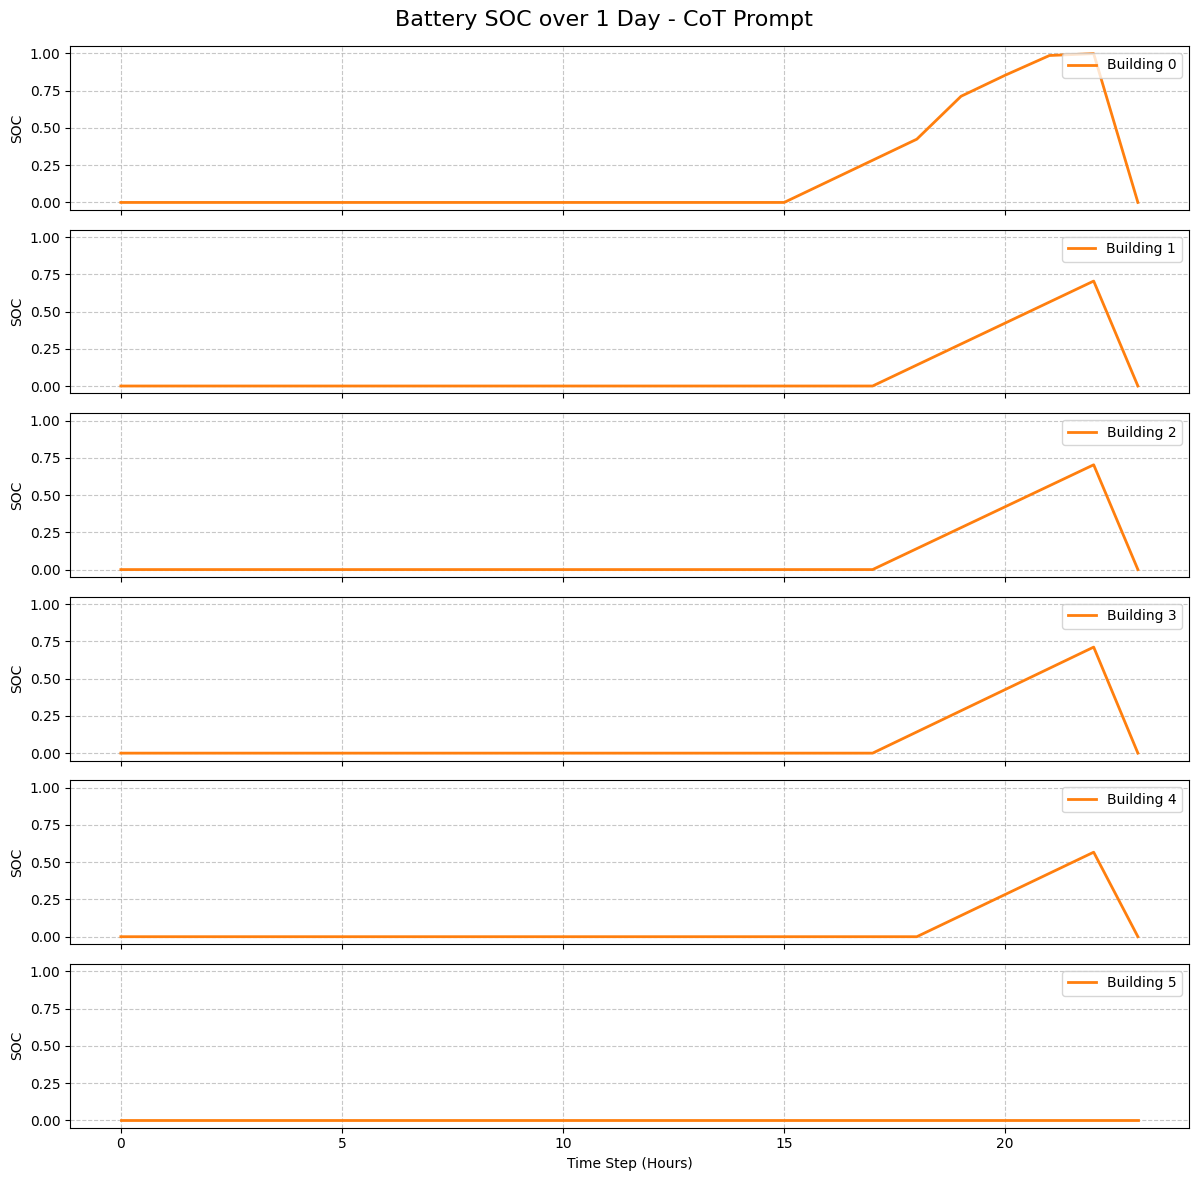

In [25]:
import time
from src.env import snapshot_state
from src.sft import render_state
import pandas as pd
import matplotlib.pyplot as plt

print("=== 1-DAY CoT EVALUATION ===")
# 24 steps = 1 day
env_cot = make_colab_env(start=EVAL_START, end=EVAL_START+23)
env_cot.reset()

done, t, t0, n_fb = False, 0, time.time(), 0

while not done:
    snap = snapshot_state(env_cot)
    state_text = render_state(snap)

    # Use the CoT system prompt and allow more tokens for the thought block
    acts, raw, fb = slm.step(state_text, system=sys_p_cot, n_buildings=N_BUILDINGS, max_tokens=250)

    n_fb += int(fb)
    _, _, term, trunc, _ = env_cot.step([[float(a)] for a in acts])
    done = bool(term or trunc)

    if t % 6 == 0:
        print(f"  t={t:2d} | fallbacks={n_fb}")
    t += 1

print(f"Done in {time.time()-t0:.1f}s | fallbacks={n_fb}/{t}")

# Evaluate KPIs
df_cot = env_cot.evaluate()
df_cot['Policy'] = 'CoT (1 Day)'
display(df_cot[df_cot['level'] == 'district'][['cost_function', 'value']])

# Plot SOC
fig, axes = plt.subplots(nrows=N_BUILDINGS, ncols=1, figsize=(12, 2 * N_BUILDINGS), sharex=True)
if N_BUILDINGS == 1: axes = [axes]

for i, b in enumerate(env_cot.buildings):
    axes[i].plot(b.electrical_storage.soc, label=f'Building {i}', color='tab:orange', linewidth=2)
    axes[i].set_ylabel('SOC')
    axes[i].set_ylim(-0.05, 1.05)
    axes[i].legend(loc='upper right')
    axes[i].grid(True, linestyle='--', alpha=0.7)

axes[-1].set_xlabel('Time Step (Hours)')
fig.suptitle('Battery SOC over 1 Day - CoT Prompt', fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()